In [1]:
cd ../src/train_VAE/

/home/rfit/Telescope_Array/phd_work/src/train_VAE


In [6]:
!export CUDA_VISIBLE_DEVICES=2

In [7]:
import h5py as h5
import numpy as np
import os
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
data_path = '/home3/rfit/Telescope_Array/phd_work/data/normed/pr_photon_0001_excl_sat_T_excl_geo_T_one_work.h5'

In [8]:
try:
    import importlib
    importlib.reload(pipline)
except NameError:
    import pipline

Using device: cuda


In [5]:
!export CUDA_VISIBLE_DEVICES=3

In [9]:
pip = pipline.Pipline(config = 'config.yaml')

['catboost_info', 'pipline.py', '__pycache__', 'model_old.py', 'metric.py', 'runs', 'datasets.py', 'runs_tests', 'model.py', 'loss.py', 'tests', 'utils.py', 'init.sh', 'config.yaml', '__init__.py', 'for_temporary_work', '.ipynb_checkpoints']


RuntimeError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call,so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.

In [ ]:
pip.load_chpt(chpt_path = '/home/rfit/Telescope_Array/phd_work/Models/AutoEncoder/small_decoder_VAE_V8/last')

load False format. If it is 'FALSE' we worning


In [17]:
self = pip
import loss as Loss
from typing import Tuple
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def validation_step(self, epoch: int, val_loader, model,
                koef_KL=1, koef_DL=1, particle=None,
                reduce_loss_per_event = False) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Одна итерация валидации по одному типу частиц.

    Аргументы:
        epoch (int): Номер текущей эпохи.
        val_loader (DataLoader): DataLoader с тестовыми данными.
        model (nn.Module): Модель.
        koef_KL (float): Вес для KL-дивергенции.
        koef_DL (float): Вес для потерь по числу детекторов.
        particle (str, optional): Имя типа частицы.

    Возвращает:
        Кортеж numpy-массивов: полные потери, KL, реконструкция и число детекторов.
    """
    particle = '' if particle is None else particle
    loss_mean = []
    KL_loss_mean = []
    recon_loss_mean = []
    num_det_loss_mean = []
    recon_params_loss_mean = [0]*len(self.config['reconstruction_params'])
    embading = np.zeros((0, self.config['latent_dim']))
    pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")
    num_examples = 0
    for x, part, params_CR in pbar_val:  # x should be a batch of sequences with padding
        num_examples += x.size(0)

        with torch.no_grad():
            x = x.to(device)
            part = torch.where(part == 1, 0, 1).to(device) # 0- photon, 1- proton
            params_CR = params_CR.to(device) 
            recon_x, mu, log_var, pred_num, recon_pred = model(x)
            recon_loss, kl_divergence, num_det_loss, recon_params_loss = Loss.vae_loss(recon_x, x, mu, log_var, pred_num,
                                                                                    recon_pred,
                                                                                    params_CR, 
                                                                                    part,
                                                                                    mask=self.mask,
                                                                                    use_mask=self.use_mask,
                                                                                    koef_loss=self.koef_loss,
                                                                                    reduce_loss_per_event = reduce_loss_per_event

                                                                                    )
            embading = np.concatenate((embading, mu.cpu().detach().numpy()), axis=0)
            # kl_divergence *= koef_KL
            # num_det_loss *= koef_DL
            # recon_params_loss *= self.koef_mass
            loss = recon_loss + kl_divergence*koef_KL + num_det_loss*koef_DL + torch.mean(recon_params_loss)*self.koef_mass
            loss_mean.append(loss.item())
            KL_loss_mean.append(kl_divergence.item())
            recon_loss_mean.append(recon_loss.to('cpu').item())
            num_det_loss_mean.append(num_det_loss.item())
            for i,par in enumerate(recon_params_loss_mean): 
                recon_params_loss_mean[i] += recon_params_loss[i].to('cpu').item()
            pbar_val.set_description(f"VAL Epoch {epoch + 1} in {particle}, Loss: {loss.item():.4f}")
    # recon_params_loss_mean = torch.concat(recon_params_loss_mean, dim=1).numpy()
    recon_params_loss_mean = np.array(recon_params_loss_mean)/num_examples
    loss_final = np.array(loss_mean).mean()
    # write in TB
    self.writer.add_scalar(f"val/Loss/{particle}", loss_final, epoch)
    self.writer.add_scalar(f"val/KL_loss/{particle}", np.array(KL_loss_mean).mean(), epoch)
    self.writer.add_scalar(f"val/recon_loss/{particle}", np.array(recon_loss_mean).mean(), epoch)
    self.writer.add_scalar(f"val/num_det_loss/{particle}", np.array(num_det_loss_mean).mean(), epoch)

    return np.array(loss_mean), np.array(KL_loss_mean), np.array(recon_loss_mean), np.array(num_det_loss_mean), embading
    

model = self.model
val_loaders = self.val_loaders
koef_KL = self.koef_KL
koef_DL = self.koef_DL

model.eval()
loss_mean = np.array([])
KL_loss_mean = np.array([])
recon_loss_mean = np.array([])
num_det_loss_mean = np.array([])
embading_dict = {}
recon_loss_dict = {}
KL_loss_dict = {}
for i, val_loader in enumerate(val_loaders):
    particle = self.config['paticles']['test'][i]
    loss, KL, recon, num_det, embading = validation_step(self, epoch=-1, val_loader=val_loader, model=model, koef_KL=koef_KL, koef_DL=koef_DL,particle=particle,reduce_loss_per_event  =True )
    loss_mean = np.concatenate((loss_mean, loss))
    KL_loss_mean = np.concatenate((KL_loss_mean, KL))
    recon_loss_mean = np.concatenate((recon_loss_mean, recon))
    num_det_loss_mean = np.concatenate((num_det_loss_mean, num_det))
    # все что выше можно потом убрать 
    recon_loss_dict[particle] = recon
    KL_loss_dict[particle] = KL
    embading_dict[particle] = embading
    loss_final = loss_mean.mean()

VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/7791 [00:00<?, ?it/s]/home/rfit/Telescope_Array/phd_work/src/train_VAE/datasets.py:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x), torch.tensor(mc_params[1]), torch.tensor(params_CR)
VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/7791 [00:00<?, ?it/s]


ValueError: only one element tensors can be converted to Python scalars

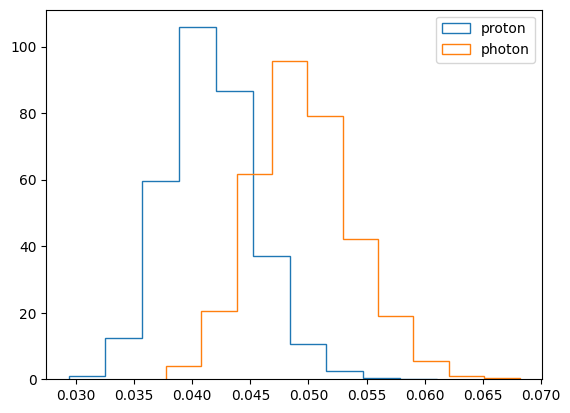

In [9]:
plt.hist(recon_loss_dict['pr'], histtype = 'step', density = True, label = 'proton')
plt.hist(recon_loss_dict['photon'], histtype = 'step', density = True, label = 'photon')
plt.legend()
plt.show()

In [13]:
recon_loss_dict['pr'].shape

(7791,)

In [12]:
print('pr mean',recon_loss_dict['pr'].mean())
print('photon mean',recon_loss_dict['photon'].mean())   
print('pr std',recon_loss_dict['pr'].std())
print('photon std',recon_loss_dict['photon'].std())


pr mean 0.04163580022043662
photon mean 0.04962298422438618
pr std 0.0036725257088055983
photon std 0.004260670627594391


<Axes: title={'center': 'Receiver Operating Characteristic (ROC) Curve'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

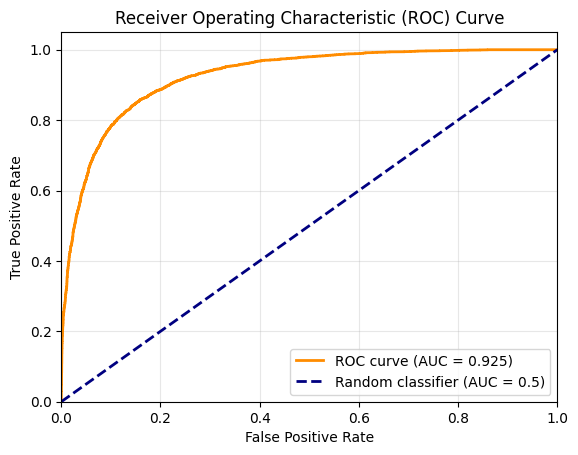

In [11]:
from sklearn.metrics import f1_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_curve, auc, roc_auc_score
def plot_roc_curve( loss_pr, loss_ph, ax):
    """
    Строит ROC кривую и вычисляет AUC
    
    Args:
        y_true: истинные метки (0 или 1)
        y_scores: вероятности положительного класса (второй столбец из softmax)
        epoch: номер эпохи для логирования
    """
    label_pr = np.zeros_like(loss_pr)
    label_ph = np.ones_like(loss_ph)
    label = np.concatenate((label_pr, label_ph))
    loss = np.concatenate((loss_pr, loss_ph))
    # Вычисляем ROC кривую
    fpr, tpr, thresholds = roc_curve(label, loss)
    roc_auc = auc(fpr, tpr)
    
    # Создаем график
    ax.plot(fpr, tpr, color='darkorange', lw=2, 
            label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
            label='Random classifier (AUC = 0.5)')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('Receiver Operating Characteristic (ROC) Curve')
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    return ax
fig, ax = plt.subplots()
plot_roc_curve(recon_loss_dict['pr'], recon_loss_dict['photon'], ax)